In [2]:

import os
os.chdir('/home/svs25/SAE')

os.CUDA_VISIBLE_DEVICES = "1"


In [3]:
from __future__ import annotations

import heapq
import json
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import torch

from topk_sae.dataset.memmap_dataset import ActivationMemmap
from topk_sae.models.train_topk_sae import TopKSAE

# Inspect trained Top-K SAE latents on ProGen-3 layer-6 activations

We'd like to:

1. Load a trained SAE checkpoint (`best.pt`)
2. Load the memmap activations
3. Load the raw `.pt` file containing `sequence_ids` and `token_positions`
4. Load the processed CSV containing the original sequences
5. Compute latent usage statistics
6. Store top-activating examples for each latent
7. Label each top example as either a special ProGen-3 token or a real amino-acid position

Confirmed tokenization structure from your earlier inspection:

`['', '1', sequence..., '2', '']`

So for an amino-acid sequence of length `L`:

- token position `0` = special wrapper
- token position `1` = start marker `'1'`
- token positions `2..L+1` = real amino acids
- token position `L+2` = end marker `'2'`
- token position `L+3` = special wrapper

In [4]:
# --- User-configurable paths ---
REPO_ROOT = Path(".")

# Checkpoint from training
CKPT_PATH = REPO_ROOT / "results/topk_sae_layer6_d4096_k32_run1/best.pt"

# Train memmap / metadata
MEMMAP_BIN = REPO_ROOT / "data/embeddings_memmap/layer6/s1a70_train_acts.f16.bin"
MEMMAP_META = REPO_ROOT / "data/embeddings_memmap/layer6/s1a70_train_acts.meta.json"

# Raw flattened activations with sequence_ids and token_positions
RAW_PT_PATH = REPO_ROOT / "data/embeddings/s1a70_train_layer6_raw.pt"

# Processed CSV with original sequences
CSV_PATH = REPO_ROOT / "data/processed/s1a70/s1a70_train.csv"

# Where outputs from this notebook will be written
OUTPUT_DIR = REPO_ROOT / "results/topk_sae_layer6_d4096_k32_run1/analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Compute settings
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2048

# Use MAX_ROWS = None for full pass; set smaller for quick debugging
MAX_ROWS = None

# How many top activating examples to keep per latent
TOP_EXAMPLES_PER_LATENT = 10

print("Device:", DEVICE)
print("Checkpoint exists:", CKPT_PATH.exists())
print("Memmap exists:", MEMMAP_BIN.exists(), MEMMAP_META.exists())
print("Raw pt exists:", RAW_PT_PATH.exists())
print("CSV exists:", CSV_PATH.exists())
print("Output dir:", OUTPUT_DIR)

Device: cuda
Checkpoint exists: True
Memmap exists: True True
Raw pt exists: True
CSV exists: True
Output dir: results/topk_sae_layer6_d4096_k32_run1/analysis


## Helper functions

These helpers:

- load the checkpoint and rebuild the SAE
- load sequences from the CSV
- map token positions to either special tokens or amino-acid indices
- build a compact summary for each top-activating example

In [5]:
def load_model_from_checkpoint(ckpt_path: Path, device: str = "cpu"):
    ckpt = torch.load(ckpt_path, map_location="cpu")

    config = ckpt["config"]
    model = TopKSAE(
        d_in=config["d_in"],
        d_sae=config["d_sae"],
        k=config["k"],
        use_pre_bias=True,
        use_post_bias=True,
        normalize_decoder=True,
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(device)
    model.eval()

    input_mean = ckpt.get("input_mean", None)
    input_std = ckpt.get("input_std", None)
    if input_mean is not None:
        input_mean = input_mean.to(device)
    if input_std is not None:
        input_std = input_std.to(device)

    return model, ckpt, input_mean, input_std


def load_sequences_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    if "sequence" not in df.columns:
        raise ValueError(f"{csv_path} must contain a sequence column")
    return df.reset_index(drop=True)


def map_token_position_to_annotation(token_position: int, sequence: str):
    """
    ProGen-3 token layout inferred from earlier inspection:
        [special, '1', aa_0, aa_1, ..., aa_{L-1}, '2', special]

    Therefore, for sequence length L:
        0       -> special wrapper
        1       -> start marker '1'
        2..L+1  -> amino acids
        L+2     -> end marker '2'
        L+3     -> special wrapper
    """
    L = len(sequence)

    if token_position == 0:
        return {
            "token_type": "special",
            "special_name": "bos_or_wrapper",
            "aa_index": None,
            "amino_acid": None,
            "local_window": None,
        }

    if token_position == 1:
        return {
            "token_type": "special",
            "special_name": "start_marker_1",
            "aa_index": None,
            "amino_acid": None,
            "local_window": None,
        }

    if 2 <= token_position <= L + 1:
        aa_index = token_position - 2
        aa = sequence[aa_index]
        local_window = sequence[max(0, aa_index - 10): min(L, aa_index + 11)]
        return {
            "token_type": "amino_acid",
            "special_name": None,
            "aa_index": aa_index,
            "amino_acid": aa,
            "local_window": local_window,
        }

    if token_position == L + 2:
        return {
            "token_type": "special",
            "special_name": "end_marker_2",
            "aa_index": None,
            "amino_acid": None,
            "local_window": None,
        }

    if token_position == L + 3:
        return {
            "token_type": "special",
            "special_name": "eos_or_wrapper",
            "aa_index": None,
            "amino_acid": None,
            "local_window": None,
        }

    return {
        "token_type": "unknown",
        "special_name": "out_of_range",
        "aa_index": None,
        "amino_acid": None,
        "local_window": None,
    }


def make_example_record(row_idx: int, activation_value: float, sequence_id: int, token_position: int, sequence: str):
    ann = map_token_position_to_annotation(token_position, sequence)
    rec = {
        "activation_value": float(activation_value),
        "row_idx": int(row_idx),
        "sequence_id": int(sequence_id),
        "token_position": int(token_position),
        "sequence_length_aa": int(len(sequence)),
        "sequence": sequence,
    }
    rec.update(ann)
    return rec

In [7]:
model, ckpt, input_mean, input_std = load_model_from_checkpoint(CKPT_PATH, device=DEVICE)
dataset = ActivationMemmap(MEMMAP_BIN, MEMMAP_META)
raw = torch.load(RAW_PT_PATH, map_location="cpu")
seq_df = load_sequences_df(CSV_PATH)

sequence_ids = raw["sequence_ids"]
token_positions = raw["token_positions"]
lengths = raw["lengths"]

n_rows_total = len(dataset)
n_rows = n_rows_total if MAX_ROWS is None else min(n_rows_total, MAX_ROWS)

print("Checkpoint config:", ckpt["config"])
print("Dataset rows total:", n_rows_total)
print("Rows to inspect:", n_rows)
print("sequence_ids shape:", tuple(sequence_ids.shape))
print("token_positions shape:", tuple(token_positions.shape))
print("lengths shape:", tuple(lengths.shape))
print("CSV rows:", len(seq_df))

assert sequence_ids.shape[0] >= n_rows
assert token_positions.shape[0] >= n_rows
assert len(seq_df) == lengths.shape[0], "CSV row count should match lengths count"

/tmp/ipykernel_3258565/1601052609.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")
/tmp/ipykernel_3258565/2698988319.py:3

Checkpoint config: {'d_in': 384, 'd_sae': 4096, 'k': 32}
Dataset rows total: 10271296
Rows to inspect: 10271296
sequence_ids shape: (10271296,)
token_positions shape: (10271296,)
lengths shape: (38318,)
CSV rows: 38318


## Check one or two mappings by hand

This is just a sanity check that a raw row maps sensibly back to a sequence and token position.

In [8]:
for row_idx in [0, 1, 2, 1000, 50000]:
    if row_idx >= n_rows:
        continue
    seq_id = int(sequence_ids[row_idx].item())
    tok_pos = int(token_positions[row_idx].item())
    seq = seq_df.iloc[seq_id]["sequence"]
    print("row_idx=", row_idx, "seq_id=", seq_id, "tok_pos=", tok_pos)
    print(make_example_record(row_idx, 0.0, seq_id, tok_pos, seq))
    print("-" * 80)

row_idx= 0 seq_id= 0 tok_pos= 0
{'activation_value': 0.0, 'row_idx': 0, 'sequence_id': 0, 'token_position': 0, 'sequence_length_aa': 269, 'sequence': 'MIRTLLLSTLVAGALSCGDPTYPPYVTRVVGGEEARPNSWPWQVSLQYSSNGKWYHTCGGSLIANSWVLTAAHCISSSRTYRVGLGRHNLYVAESGSLAVSVSKIVVHKDWNSNQISKGNDIALLKLANPVSLTDKIQLACLPPAGTILPNNYPCYVTGWGRLQTNGAVPDVLQQGRLLVVDYATCSSSAWWGSSVKTSMICAGGDGVISSCNGDSGGPLNCQASDGRWQVHGIVSFGSRLGCNYYHKPSVFTRVSNYIDWINSVIANN', 'token_type': 'special', 'special_name': 'bos_or_wrapper', 'aa_index': None, 'amino_acid': None, 'local_window': None}
--------------------------------------------------------------------------------
row_idx= 1 seq_id= 0 tok_pos= 1
{'activation_value': 0.0, 'row_idx': 1, 'sequence_id': 0, 'token_position': 1, 'sequence_length_aa': 269, 'sequence': 'MIRTLLLSTLVAGALSCGDPTYPPYVTRVVGGEEARPNSWPWQVSLQYSSNGKWYHTCGGSLIANSWVLTAAHCISSSRTYRVGLGRHNLYVAESGSLAVSVSKIVVHKDWNSNQISKGNDIALLKLANPVSLTDKIQLACLPPAGTILPNNYPCYVTGWGRLQTNGAVPDVLQQGRLLVVDYATCSSSAWWGSSVKTSMICAGGDGVISSCNGDSGGPLNCQASD

## Main inspection pass

This iterates sequentially through the memmap and tracks for each latent:

- `fire_count`: how many token rows activated that latent
- `fire_fraction`: `fire_count / n_rows`
- `mean_active_value`: mean activation magnitude among rows where the latent fired
- `max_value`: max activation ever seen
- top activating examples

Because this is a Top-K SAE, `z` is sparse, so iterating over nonzero entries is tractable.

In [9]:
# Find backing memmap array on the dataset object.
# This assumes your ActivationMemmap exposes one of these attributes.
backing = None
for attr in ["_arr", "arr", "_memmap", "memmap", "data"]:
    if hasattr(dataset, attr):
        backing = getattr(dataset, attr)
        print("Using backing attribute:", attr)
        break

if backing is None:
    raise RuntimeError(
        "Could not find backing memmap array on ActivationMemmap. "
        "Expose one of _arr/arr/_memmap/memmap/data or add a sequential loader method."
    )

Using backing attribute: _arr


In [10]:
BATCH_SIZE = 2048  # safer for inspection

d_sae = ckpt["config"]["d_sae"]

fire_count = torch.zeros(d_sae, dtype=torch.long)
active_sum = torch.zeros(d_sae, dtype=torch.float64)
max_value = torch.full((d_sae,), float("-inf"), dtype=torch.float64)

# For each latent keep a min-heap of (activation_value, row_idx)
top_heaps = [[] for _ in range(d_sae)]

model.eval()

with torch.inference_mode():
    for start in range(0, n_rows, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_rows)

        # Load a sequential chunk from the memmap
        x = torch.tensor(backing[start:end], dtype=torch.float32, device=DEVICE)

        # Apply the same normalization used during training
        if input_mean is not None and input_std is not None:
            x = (x - input_mean) / input_std

        # Forward pass
        out = model(x)
        z = out["z"]  # [batch, d_sae]

        # Move z to CPU once, then do all summary ops there
        z_cpu = z.cpu()

        active_mask_cpu = z_cpu > 0

        fire_count += active_mask_cpu.sum(dim=0)
        active_sum += z_cpu.sum(dim=0).double()
        batch_max = z_cpu.max(dim=0).values.double()
        max_value = torch.maximum(max_value, batch_max)

        # Since z is sparse, inspect only the nonzero entries
        nz_rows, nz_cols = torch.nonzero(active_mask_cpu, as_tuple=True)
        for local_row, latent_idx in zip(nz_rows.tolist(), nz_cols.tolist()):
            global_row = start + local_row
            val = float(z_cpu[local_row, latent_idx].item())

            heap = top_heaps[latent_idx]
            if len(heap) < TOP_EXAMPLES_PER_LATENT:
                heapq.heappush(heap, (val, global_row))
            else:
                if val > heap[0][0]:
                    heapq.heapreplace(heap, (val, global_row))

        if start % (100 * BATCH_SIZE) == 0:
            print(f"Processed rows {start:,} to {end:,}")

        # Explicit cleanup helps in notebooks
        del x, out, z, z_cpu, active_mask_cpu, batch_max, nz_rows, nz_cols

        if DEVICE.startswith("cuda"):
            torch.cuda.empty_cache()

Processed rows 0 to 2,048
Processed rows 204,800 to 206,848
Processed rows 409,600 to 411,648
Processed rows 614,400 to 616,448
Processed rows 819,200 to 821,248
Processed rows 1,024,000 to 1,026,048
Processed rows 1,228,800 to 1,230,848
Processed rows 1,433,600 to 1,435,648
Processed rows 1,638,400 to 1,640,448
Processed rows 1,843,200 to 1,845,248
Processed rows 2,048,000 to 2,050,048
Processed rows 2,252,800 to 2,254,848
Processed rows 2,457,600 to 2,459,648
Processed rows 2,662,400 to 2,664,448
Processed rows 2,867,200 to 2,869,248
Processed rows 3,072,000 to 3,074,048
Processed rows 3,276,800 to 3,278,848
Processed rows 3,481,600 to 3,483,648
Processed rows 3,686,400 to 3,688,448
Processed rows 3,891,200 to 3,893,248
Processed rows 4,096,000 to 4,098,048
Processed rows 4,300,800 to 4,302,848
Processed rows 4,505,600 to 4,507,648
Processed rows 4,710,400 to 4,712,448
Processed rows 4,915,200 to 4,917,248
Processed rows 5,120,000 to 5,122,048
Processed rows 5,324,800 to 5,326,848
Pr

In [11]:
fire_fraction = fire_count.double() / float(n_rows)
mean_active_value = torch.zeros(d_sae, dtype=torch.float64)
nonzero_mask = fire_count > 0
mean_active_value[nonzero_mask] = active_sum[nonzero_mask] / fire_count[nonzero_mask].double()

sorted_latents = torch.argsort(fire_count, descending=True).tolist()

latent_summary = []
top_examples_output = {}

for latent_idx in sorted_latents:
    latent_summary.append({
        "latent_idx": int(latent_idx),
        "fire_count": int(fire_count[latent_idx].item()),
        "fire_fraction": float(fire_fraction[latent_idx].item()),
        "mean_active_value": float(mean_active_value[latent_idx].item()),
        "max_value": float(max_value[latent_idx].item()),
    })

    examples = sorted(top_heaps[latent_idx], key=lambda x: x[0], reverse=True)
    recs = []
    for val, row_idx in examples:
        seq_id = int(sequence_ids[row_idx].item())
        tok_pos = int(token_positions[row_idx].item())
        seq = seq_df.iloc[seq_id]["sequence"]
        recs.append(make_example_record(row_idx, val, seq_id, tok_pos, seq))
    top_examples_output[str(latent_idx)] = recs

print("Total latents summarized:", len(latent_summary))
print("Example top summary record:")
print(latent_summary[0])

Total latents summarized: 4096
Example top summary record:
{'latent_idx': 2491, 'fire_count': 2146352, 'fire_fraction': 0.20896603505536204, 'mean_active_value': 6.223986398193479, 'max_value': 11.579072952270508}


In [12]:
summary_path = OUTPUT_DIR / "latent_summary.json"
examples_path = OUTPUT_DIR / "top_examples.json"

with summary_path.open("w") as f:
    json.dump(latent_summary, f, indent=2)

with examples_path.open("w") as f:
    json.dump(top_examples_output, f, indent=2)

print("Saved:", summary_path)
print("Saved:", examples_path)

Saved: results/topk_sae_layer6_d4096_k32_run1/analysis/latent_summary.json
Saved: results/topk_sae_layer6_d4096_k32_run1/analysis/top_examples.json


In [13]:
summary_df = pd.DataFrame(latent_summary)
summary_df.head(30)

,latent_idx,fire_count,fire_fraction,mean_active_value,max_value
0,2491,2146352,0.208966,6.223986,11.579073
1,3034,1633556,0.159041,1.015022,6.446189
2,474,1573335,0.153178,2.079281,7.984866
3,3691,1391219,0.135447,0.981014,5.741388
4,24,1318787,0.128395,0.919013,6.838675
5,3362,1294544,0.126035,1.388310,16.154272
6,1747,1288637,0.125460,1.458099,9.844698
7,2973,1262065,0.122873,1.877896,10.859170
8,3701,1230745,0.119824,1.292457,9.610744
9,1105,1183856,0.115259,1.140176,6.674235


In [14]:
summary_df.tail(20)

,latent_idx,fire_count,fire_fraction,mean_active_value,max_value
4076,1932,2,1.947174e-07,0.493964,0.494576
4077,3791,1,9.735870e-08,0.364611,0.364611
4078,2565,1,9.735870e-08,0.651349,0.651349
4079,2281,1,9.735870e-08,0.407733,0.407733
4080,3416,1,9.735870e-08,0.712908,0.712908
4081,2359,1,9.735870e-08,0.539934,0.539934
4082,2403,1,9.735870e-08,0.489692,0.489692
4083,3272,0,0.000000e+00,0.000000,0.000000
4084,2085,0,0.000000e+00,0.000000,0.000000
4085,3087,0,0.000000e+00,0.000000,0.000000


## Which latents fire mostly on special tokens?

This is useful because latents that mostly fire on wrapper/start/end tokens are probably learning formatting/boundary structure rather than protein biology.

In [15]:
special_fraction_records = []

for latent_idx_str, recs in top_examples_output.items():
    if len(recs) == 0:
        frac_special = None
    else:
        frac_special = sum(r["token_type"] == "special" for r in recs) / len(recs)
    special_fraction_records.append({
        "latent_idx": int(latent_idx_str),
        "top_examples_special_fraction": frac_special,
    })

special_df = pd.DataFrame(special_fraction_records)
merged_df = summary_df.merge(special_df, on="latent_idx", how="left")
merged_df.sort_values(["top_examples_special_fraction", "fire_count"], ascending=[False, False]).head(30)

,latent_idx,fire_count,fire_fraction,mean_active_value,max_value,top_examples_special_fraction
950,3582,83313,0.008111,10.645948,19.161196,1.0
997,1864,79651,0.007755,4.699705,6.303859,1.0
1018,3101,77894,0.007584,5.183201,10.232219,1.0
1044,520,76749,0.007472,15.310966,16.411152,1.0
1500,2628,51057,0.004971,6.731121,14.306834,1.0
1550,1280,49208,0.004791,2.852257,9.514955,1.0
1570,1530,48647,0.004736,5.439620,13.394400,1.0
1637,186,46855,0.004562,3.226191,9.226501,1.0
1646,414,46629,0.004540,7.673989,16.105812,1.0
1649,334,46604,0.004537,3.025803,8.221464,1.0


In [16]:
# Keep only latents whose top examples never hit boundary/special tokens
non_boundary_df = merged_df[
    merged_df["top_examples_special_fraction"] == 0.0
].copy()

# Apply your biological relevance thresholds
candidate_latents = non_boundary_df[
    (non_boundary_df["fire_fraction"] >= 0.001) &
    (non_boundary_df["fire_fraction"] <= 0.03) &
    (non_boundary_df["mean_active_value"] >= 3.0) &
    (non_boundary_df["max_value"] >= 8.0)
].copy()

# Sort for inspection
candidate_latents = candidate_latents.sort_values(
    ["mean_active_value", "max_value", "fire_fraction"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Total latents:", len(summary_df))
print("Non-boundary latents:", len(non_boundary_df))
print("Candidate biological latents:", len(candidate_latents))

candidate_latents.sort_values(["mean_active_value"], ascending=False).head(30)

Total latents: 4096
Non-boundary latents: 3960
Candidate biological latents: 205


,latent_idx,fire_count,fire_fraction,mean_active_value,max_value,top_examples_special_fraction
0,751,38462,0.003745,14.139578,15.252412,0.0
1,1518,35983,0.003503,12.937562,13.172389,0.0
2,3228,54536,0.005310,12.801907,68.831543,0.0
3,2864,38927,0.003790,12.463821,13.453701,0.0
4,544,38469,0.003745,10.718019,11.427633,0.0
5,1723,24390,0.002375,10.392848,23.908321,0.0
6,2500,21222,0.002066,10.348625,22.440277,0.0
7,3818,35329,0.003440,10.089001,10.098669,0.0
8,202,39034,0.003800,9.927678,10.715335,0.0
9,234,35854,0.003491,9.798311,9.942190,0.0


In [18]:
from collections import Counter
import pandas as pd

LATENT_TO_INSPECT = 3228
#int(candidate_latents.iloc[0]["latent_idx"])

print("Inspecting latent:", LATENT_TO_INSPECT)
print(candidate_latents[candidate_latents["latent_idx"] == LATENT_TO_INSPECT])

examples_df = pd.DataFrame(top_examples_output[str(LATENT_TO_INSPECT)])

examples_df.to_csv(OUTPUT_DIR / f"latent{LATENT_TO_INSPECT}_toptokenlevel_summary.csv", index=False)

examples_df.head(30)

Inspecting latent: 3228
   latent_idx  fire_count  fire_fraction  mean_active_value  max_value  \
2        3228       54536        0.00531          12.801907  68.831543   

   top_examples_special_fraction  
2                            0.0  


,activation_value,row_idx,sequence_id,token_position,sequence_length_aa,sequence,token_type,special_name,aa_index,amino_acid,local_window
0,68.831543,4540137,17924,77,239,MNKNIIIKSIAALTILTSITGVGTTMVEGIQQTAKAENTVKQITNT...,amino_acid,None,75,V,GNHTIITNKHVTYHMKVGDEI
1,65.258415,7578258,29514,119,282,MKKRFLSICTMTIAALATTTMVNTSYAKTDTESHNHSSLGTENKNV...,amino_acid,None,117,V,GENEILTNKHVVNGAKGNPRN
2,60.050526,3167495,11964,78,284,TCQRLTMCYFLPLVCGQPSRALPTLVKRIIGGRNAEPGFFPWQALI...,amino_acid,None,76,V,SESWVLTAAHVLQHVNVYLGL
3,59.715809,304523,1150,81,239,MRITRIIPALLAALLAVLTLSSAATAAEDRAPAKVSGPQPIIGGQL...,amino_acid,None,79,C,APEWILTARHCVSGGGLSFRI
4,59.715385,2977256,11246,48,242,MENLPLDPMDYAQNGEFPWTIALFSRGSFFGGGSLIAPGVVLTAAH...,amino_acid,None,46,L,APGVVLTAAHLLLSKTSHEIV
5,59.313465,2386551,9015,83,241,MRITRIIPALLAALLSVLTLAGTATAAQAEDRAATKVSGPQPIIGG...,amino_acid,None,81,C,APTWILTARHCVSGGGLSFRI
6,59.168747,1815728,6867,85,291,MGTNLLFIIYLLTMCYFLPLVCGQPSRALPTLVKRIIGGRNAEPGF...,amino_acid,None,83,V,SESWVLTAAHVLQHVNVYLGL
7,59.162518,3437336,12990,101,294,MQPAYSSKTIKSTSKIFSFSVDTDKLDPHLCLCLLPVCGQPARQLP...,amino_acid,None,99,V,SDSWVLTAAHVLRSPRRDNTV
8,59.137360,826217,3128,43,270,MPGLFPWQVLLQVEDRSRVPEDRWFGSGALLSPSWILTAAHLLRSQ...,amino_acid,None,41,L,SPSWILTAAHLLRSQRRDNSV
9,58.915215,430014,1634,56,257,LKTFLSGLCSGAIVGGYTPSPNSIKYIVSLQSSKSQHFCGGSLVHK...,amino_acid,None,54,L,HKSWVLTAAHLSVSSLLLKYG


## Activation distribution along sequence

We want to know where a particular latent fires along any given sequence

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

LATENT_TO_INSPECT = 3228
BATCH_SIZE = 2048

latent_token_records = []

model.eval()

with torch.inference_mode():
    for start in range(0, n_rows, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_rows)

        # Load a sequential chunk from the memmap
        x = torch.tensor(backing[start:end], dtype=torch.float32, device=DEVICE)

        # Apply the same normalization used during training
        if input_mean is not None and input_std is not None:
            x = (x - input_mean) / input_std

        # Forward pass
        out = model(x)
        z = out["z"][:, LATENT_TO_INSPECT].cpu()  # [batch]

        active_rows = torch.nonzero(z > 0, as_tuple=True)[0]

        for local_row in active_rows.tolist():
            global_row = start + local_row
            val = float(z[local_row].item())

            seq_id = int(sequence_ids[global_row].item())
            tok_pos = int(token_positions[global_row].item())
            seq = seq_df.iloc[seq_id]["sequence"]

            ann = map_token_position_to_annotation(tok_pos, seq)

            # Keep only amino acid tokens for density analysis
            if ann["token_type"] != "amino_acid":
                continue

            aa_index = int(ann["aa_index"])
            L = len(seq)

            # safer normalization; avoids division by zero for tiny sequences
            relative_pos = aa_index / max(L - 1, 1)

            latent_token_records.append({
                "row_idx": global_row,
                "sequence_id": seq_id,
                "token_position": tok_pos,
                "aa_index": aa_index,
                "sequence_length_aa": L,
                "relative_pos": relative_pos,
                "activation_value": val,
            })

        if start % (100 * BATCH_SIZE) == 0:
            print(f"Processed rows {start:,} to {end:,}")

        del x, out, z, active_rows
        if DEVICE.startswith("cuda"):
            torch.cuda.empty_cache()

latent_token_df = pd.DataFrame(latent_token_records)

print("Total active amino-acid token records:", len(latent_token_df))
latent_token_df.head()

Processed rows 0 to 2,048
Processed rows 204,800 to 206,848
Processed rows 409,600 to 411,648
Processed rows 614,400 to 616,448
Processed rows 819,200 to 821,248
Processed rows 1,024,000 to 1,026,048
Processed rows 1,228,800 to 1,230,848
Processed rows 1,433,600 to 1,435,648
Processed rows 1,638,400 to 1,640,448
Processed rows 1,843,200 to 1,845,248
Processed rows 2,048,000 to 2,050,048
Processed rows 2,252,800 to 2,254,848
Processed rows 2,457,600 to 2,459,648
Processed rows 2,662,400 to 2,664,448
Processed rows 2,867,200 to 2,869,248
Processed rows 3,072,000 to 3,074,048
Processed rows 3,276,800 to 3,278,848
Processed rows 3,481,600 to 3,483,648
Processed rows 3,686,400 to 3,688,448
Processed rows 3,891,200 to 3,893,248
Processed rows 4,096,000 to 4,098,048
Processed rows 4,300,800 to 4,302,848
Processed rows 4,505,600 to 4,507,648
Processed rows 4,710,400 to 4,712,448
Processed rows 4,915,200 to 4,917,248
Processed rows 5,120,000 to 5,122,048
Processed rows 5,324,800 to 5,326,848
Pr

,row_idx,sequence_id,token_position,aa_index,sequence_length_aa,relative_pos,activation_value
0,69,0,69,67,269,0.250000,0.734651
1,75,0,75,73,269,0.272388,51.123173
2,76,0,76,74,269,0.276119,9.064855
3,329,1,56,54,269,0.201493,0.864822
4,342,1,69,67,269,0.250000,0.983880


In [22]:
label_cols = [
    "sequence_id",
    "accession",
    "entry_name",
    "class_label",
    "class_name",
    "has_ipr001314",
    "has_ps00134",
    "has_ps00135",
    "has_both_catalytic_motifs",
    "motif_class",
]

seq_labels_df = seq_df.reset_index().rename(columns={"index": "sequence_id"})[label_cols].copy()
seq_labels_df["is_s1a"] = (seq_labels_df["class_label"] == 1).astype(int)

latent_token_df = latent_token_df.merge(
    seq_labels_df[["sequence_id", "is_s1a", "accession", "entry_name", "motif_class"]],
    on="sequence_id",
    how="left"
)

latent_token_df.head(20)

,row_idx,sequence_id,token_position,aa_index,sequence_length_aa,relative_pos,activation_value,is_s1a_x,accession_x,entry_name_x,motif_class_x,is_s1a_y,accession_y,entry_name_y,motif_class_y
0,69,0,69,67,269,0.250000,0.734651,1,P08217,CEL2A_HUMAN,both_motifs,1,P08217,CEL2A_HUMAN,both_motifs
1,75,0,75,73,269,0.272388,51.123173,1,P08217,CEL2A_HUMAN,both_motifs,1,P08217,CEL2A_HUMAN,both_motifs
2,76,0,76,74,269,0.276119,9.064855,1,P08217,CEL2A_HUMAN,both_motifs,1,P08217,CEL2A_HUMAN,both_motifs
3,329,1,56,54,269,0.201493,0.864822,1,P08218,CEL2B_HUMAN,both_motifs,1,P08218,CEL2B_HUMAN,both_motifs
4,342,1,69,67,269,0.250000,0.983880,1,P08218,CEL2B_HUMAN,both_motifs,1,P08218,CEL2B_HUMAN,both_motifs
5,348,1,75,73,269,0.272388,50.476715,1,P08218,CEL2B_HUMAN,both_motifs,1,P08218,CEL2B_HUMAN,both_motifs
6,349,1,76,74,269,0.276119,7.236443,1,P08218,CEL2B_HUMAN,both_motifs,1,P08218,CEL2B_HUMAN,both_motifs
7,618,2,72,70,267,0.263158,47.583866,1,P08246,ELNE_HUMAN,both_motifs,1,P08246,ELNE_HUMAN,both_motifs
8,619,2,73,71,267,0.266917,5.379465,1,P08246,ELNE_HUMAN,both_motifs,1,P08246,ELNE_HUMAN,both_motifs
9,703,2,157,155,267,0.582707,0.405010,1,P08246,ELNE_HUMAN,both_motifs,1,P08246,ELNE_HUMAN,both_motifs


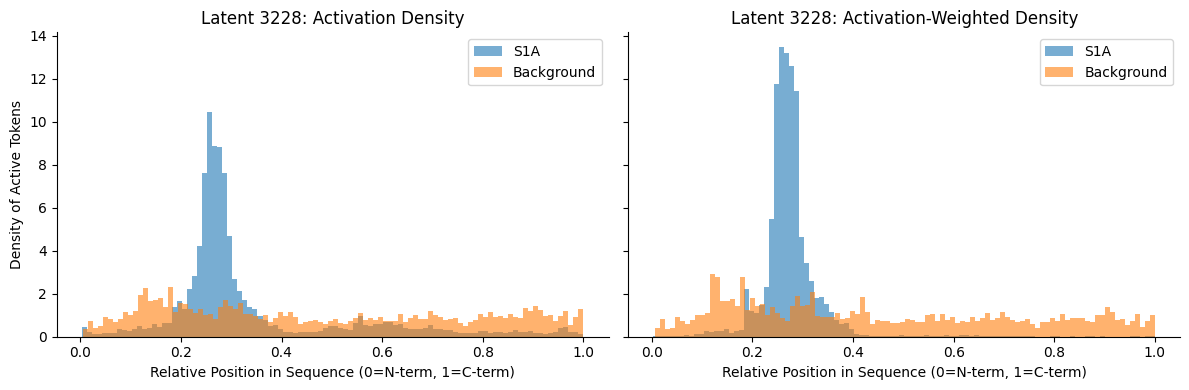

In [21]:
s1a_tokens = latent_token_df[latent_token_df["is_s1a"] == 1]
bg_tokens = latent_token_df[latent_token_df["is_s1a"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# All active amino-acid tokens
axes[0].hist(
    s1a_tokens["relative_pos"],
    bins=100,
    density=True,
    alpha=0.6,
    label="S1A"
)
axes[0].hist(
    bg_tokens["relative_pos"],
    bins=100,
    density=True,
    alpha=0.6,
    label="Background"
)
axes[0].set_title(f"Latent {LATENT_TO_INSPECT}: Activation Density")
axes[0].set_xlabel("Relative Position in Sequence (0=N-term, 1=C-term)")
axes[0].set_ylabel("Density of Active Tokens")
axes[0].legend()

# Weighted by activation value
axes[1].hist(
    s1a_tokens["relative_pos"],
    bins=100,
    density=True,
    weights=s1a_tokens["activation_value"],
    alpha=0.6,
    label="S1A"
)
axes[1].hist(
    bg_tokens["relative_pos"],
    bins=100,
    density=True,
    weights=bg_tokens["activation_value"],
    alpha=0.6,
    label="Background"
)
axes[1].set_title(f"Latent {LATENT_TO_INSPECT}: Activation-Weighted Density")
axes[1].set_xlabel("Relative Position in Sequence (0=N-term, 1=C-term)")
axes[1].legend()

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Align activating sequences for latent 3228 (this will need adjusting for any other latent)

This will align sequences in the activating window 0.2 < relative_pos > 0.35

In [24]:
region_df = latent_token_df[
    (latent_token_df["is_s1a_x"] == 1) &
    (latent_token_df["relative_pos"] > 0.20) &
    (latent_token_df["relative_pos"] < 0.35)
].copy()

print("Region-filtered active tokens:", len(region_df))
region_df.sort_values("activation_value", ascending=False).head(20)

Region-filtered active tokens: 28235


,row_idx,sequence_id,token_position,aa_index,sequence_length_aa,relative_pos,activation_value,is_s1a_x,accession_x,entry_name_x,motif_class_x,is_s1a_y,accession_y,entry_name_y,motif_class_y
36636,3167495,11964,78,76,284,0.268551,60.050526,1,A0A670ZN55,A0A670ZN55_PSETE,neither_motif,1,A0A670ZN55,A0A670ZN55_PSETE,neither_motif
3261,304523,1150,81,79,239,0.331933,59.715809,1,A0A345XT64,A0A345XT64_9ACTN,neither_motif,1,A0A345XT64,A0A345XT64_9ACTN,neither_motif
27456,2386551,9015,83,81,241,0.337500,59.313465,1,A0A345XU08,A0A345XU08_9ACTN,neither_motif,1,A0A345XU08,A0A345XU08_9ACTN,neither_motif
20667,1815728,6867,85,83,291,0.286207,59.168747,1,A0A670ZMP3,A0A670ZMP3_PSETE,neither_motif,1,A0A670ZMP3,A0A670ZMP3_PSETE,neither_motif
39909,3437336,12990,101,99,294,0.337884,59.162518,1,A0A8X7XC21,A0A8X7XC21_POLSE,serine_only,1,A0A8X7XC21,A0A8X7XC21_POLSE,serine_only
4648,430014,1634,56,54,257,0.210938,58.915215,1,A0A671NGA0,A0A671NGA0_9TELE,serine_only,1,A0A671NGA0,A0A671NGA0_9TELE,serine_only
25172,2184506,8262,83,81,241,0.337500,58.758316,1,A0ABC8BXM2,A0ABC8BXM2_9ACTN,neither_motif,1,A0ABC8BXM2,A0ABC8BXM2_9ACTN,neither_motif
37517,3249817,12276,83,81,241,0.337500,58.668022,1,A0A7K3RYG1,A0A7K3RYG1_9ACTN,neither_motif,1,A0A7K3RYG1,A0A7K3RYG1_9ACTN,neither_motif
20083,1760955,6658,83,81,241,0.337500,58.368103,1,A0A423V2M7,A0A423V2M7_STRGL,neither_motif,1,A0A423V2M7,A0A423V2M7_STRGL,neither_motif
16901,1475720,5581,83,81,241,0.337500,58.368103,1,A0AAU8KMD4,A0AAU8KMD4_9ACTN,neither_motif,1,A0AAU8KMD4,A0AAU8KMD4_9ACTN,neither_motif


In [25]:
activation_threshold = region_df["activation_value"].quantile(0.90)
print("Activation threshold (90th percentile):", activation_threshold)

high_conf_region_df = region_df[
    region_df["activation_value"] >= activation_threshold
].copy()

print("High-confidence regional tokens:", len(high_conf_region_df))
high_conf_region_df.sort_values("activation_value", ascending=False).head(20)

Activation threshold (90th percentile): 49.46920394897462
High-confidence regional tokens: 2824


,row_idx,sequence_id,token_position,aa_index,sequence_length_aa,relative_pos,activation_value,is_s1a_x,accession_x,entry_name_x,motif_class_x,is_s1a_y,accession_y,entry_name_y,motif_class_y
36636,3167495,11964,78,76,284,0.268551,60.050526,1,A0A670ZN55,A0A670ZN55_PSETE,neither_motif,1,A0A670ZN55,A0A670ZN55_PSETE,neither_motif
3261,304523,1150,81,79,239,0.331933,59.715809,1,A0A345XT64,A0A345XT64_9ACTN,neither_motif,1,A0A345XT64,A0A345XT64_9ACTN,neither_motif
27456,2386551,9015,83,81,241,0.337500,59.313465,1,A0A345XU08,A0A345XU08_9ACTN,neither_motif,1,A0A345XU08,A0A345XU08_9ACTN,neither_motif
20667,1815728,6867,85,83,291,0.286207,59.168747,1,A0A670ZMP3,A0A670ZMP3_PSETE,neither_motif,1,A0A670ZMP3,A0A670ZMP3_PSETE,neither_motif
39909,3437336,12990,101,99,294,0.337884,59.162518,1,A0A8X7XC21,A0A8X7XC21_POLSE,serine_only,1,A0A8X7XC21,A0A8X7XC21_POLSE,serine_only
4648,430014,1634,56,54,257,0.210938,58.915215,1,A0A671NGA0,A0A671NGA0_9TELE,serine_only,1,A0A671NGA0,A0A671NGA0_9TELE,serine_only
25172,2184506,8262,83,81,241,0.337500,58.758316,1,A0ABC8BXM2,A0ABC8BXM2_9ACTN,neither_motif,1,A0ABC8BXM2,A0ABC8BXM2_9ACTN,neither_motif
37517,3249817,12276,83,81,241,0.337500,58.668022,1,A0A7K3RYG1,A0A7K3RYG1_9ACTN,neither_motif,1,A0A7K3RYG1,A0A7K3RYG1_9ACTN,neither_motif
9249,815085,3086,83,81,241,0.337500,58.368103,1,A0AB33KC19,A0AB33KC19_9ACTN,neither_motif,1,A0AB33KC19,A0AB33KC19_9ACTN,neither_motif
20083,1760955,6658,83,81,241,0.337500,58.368103,1,A0A423V2M7,A0A423V2M7_STRGL,neither_motif,1,A0A423V2M7,A0A423V2M7_STRGL,neither_motif


In [27]:
WINDOW_RADIUS = 8  # gives 17-aa windows

def extract_centered_window(sequence: str, aa_index: int, radius: int = 8):
    start = aa_index - radius
    end = aa_index + radius + 1

    chars = []
    for pos in range(start, end):
        if 0 <= pos < len(sequence):
            chars.append(sequence[pos])
        else:
            chars.append("-")  # pad for alignment
    return "".join(chars)

window_records = []

for _, row in high_conf_region_df.iterrows():
    seq_id = int(row["sequence_id"])
    seq = seq_df.iloc[seq_id]["sequence"]
    aa_index = int(row["aa_index"])

    centered_window = extract_centered_window(seq, aa_index, radius=WINDOW_RADIUS)
    center_residue = seq[aa_index]

    window_records.append({
        "sequence_id": seq_id,
        "accession": row["accession_x"] if "accession_x" in row else row.get("accession", None),
        "entry_name": row["entry_name_x"] if "entry_name_x" in row else row.get("entry_name", None),
        "motif_class": row["motif_class_x"] if "motif_class_x" in row else row.get("motif_class", None),
        "aa_index": aa_index,
        "relative_pos": row["relative_pos"],
        "activation_value": row["activation_value"],
        "center_residue": center_residue,
        "centered_window": centered_window,
    })

windows_df = pd.DataFrame(window_records)
print("Number of extracted windows:", len(windows_df))

windows_csv_path = OUTPUT_DIR / f"latent{LATENT_TO_INSPECT}_highconf_windows.csv"
windows_df.to_csv(windows_csv_path, index=False)
print("Saved:", windows_csv_path)


windows_df.sort_values("activation_value", ascending=False).head(30)

Number of extracted windows: 2824
Saved: results/topk_sae_layer6_d4096_k32_run1/analysis/latent3228_highconf_windows.csv


,sequence_id,accession,entry_name,motif_class,aa_index,relative_pos,activation_value,center_residue,centered_window
2514,11964,A0A670ZN55,A0A670ZN55_PSETE,neither_motif,76,0.268551,60.050526,V,SWVLTAAHVLQHVNVYL
301,1150,A0A345XT64,A0A345XT64_9ACTN,neither_motif,79,0.331933,59.715809,C,EWILTARHCVSGGGLSF
1899,9015,A0A345XU08,A0A345XU08_9ACTN,neither_motif,81,0.337500,59.313465,C,TWILTARHCVSGGGLSF
1432,6867,A0A670ZMP3,A0A670ZMP3_PSETE,neither_motif,83,0.286207,59.168747,V,SWVLTAAHVLQHVNVYL
2712,12990,A0A8X7XC21,A0A8X7XC21_POLSE,serine_only,99,0.337884,59.162518,V,SWVLTAAHVLRSPRRDN
396,1634,A0A671NGA0,A0A671NGA0_9TELE,serine_only,54,0.210938,58.915215,L,SWVLTAAHLSVSSLLLK
1736,8262,A0ABC8BXM2,A0ABC8BXM2_9ACTN,neither_motif,81,0.337500,58.758316,C,TWILTARHCVTGGGLSF
2583,12276,A0A7K3RYG1,A0A7K3RYG1_9ACTN,neither_motif,81,0.337500,58.668022,C,TWILTAKHCVTGGGLSF
642,3086,A0AB33KC19,A0AB33KC19_9ACTN,neither_motif,81,0.337500,58.368103,C,TWILTAKHCVTGGGLSF
1384,6658,A0A423V2M7,A0A423V2M7_STRGL,neither_motif,81,0.337500,58.368103,C,TWILTAKHCVTGGGLSF


In [28]:
for w in windows_df.sort_values("activation_value", ascending=False)["centered_window"].head(30):
    print(w)

SWVLTAAHVLQHVNVYL
EWILTARHCVSGGGLSF
TWILTARHCVSGGGLSF
SWVLTAAHVLQHVNVYL
SWVLTAAHVLRSPRRDN
SWVLTAAHLSVSSLLLK
TWILTARHCVTGGGLSF
TWILTAKHCVTGGGLSF
TWILTAKHCVTGGGLSF
TWILTAKHCVTGGGLSF
TWILTAKHCVTGGGLSF
EFVMTAAHCKGRKITVI
TWILTARHCVTGGGLSF
QFVLTAAHCKGREITVT
RWVLTAAHVLSPNMQPR
TWILTARHCVTGGGLSF
RFVMTAAHCRENFQVLT
RWILTAEHCVLADPGDA
DFVMTAAHCWGSTINVI
QWVVTARHCVGSLVRAR
TWILTAKHCVTGGGLSF
DFVMTAAHCKGRKITVI
DFVMTAAHCKGRKITVI
QWVLTARHCVEAAEGAK
TWVLTARHCTHHVDNVN
RWILTSRHCINQHEPVN
RWILTAEHCVPLLQFFS
NFVLTAAHCAGRSITVL
NFVLTAAHCSGRSITVL
NFVLTAAHCAGRSITVL


In [30]:
from collections import Counter

aligned_windows = windows_df["centered_window"].tolist()
window_length = len(aligned_windows[0])

position_counts = []
for pos in range(window_length):
    residues = [w[pos] for w in aligned_windows]
    counts = Counter(residues)
    position_counts.append(counts)

freq_table = pd.DataFrame(position_counts).fillna(0).astype(int)
freq_table.index.name = "aligned_position"
freq_table.head(10)

,S,N,D,K,Q,E,R,Y,T,L,H,A,W,V,G,F,I,C,M,P
aligned_position,,,,,,,,,,,,,,,,,,,,
0,91,580,526,47,426,287,402,148,113,17,71,4,8,2,92,6,1,2,1,0
1,37,6,0,14,0,0,21,214,29,24,54,65,1572,21,0,740,22,1,4,0
2,0,0,0,0,0,0,0,0,0,23,0,6,0,2390,0,6,373,0,26,0
3,0,0,0,0,0,0,0,0,0,1936,0,2,0,210,0,0,75,0,601,0
4,91,0,0,0,0,0,0,0,2730,0,0,3,0,0,0,0,0,0,0,0
5,36,0,0,0,0,0,0,0,0,0,0,2788,0,0,0,0,0,0,0,0
6,33,2,0,19,2,31,22,6,13,0,0,2593,0,12,91,0,0,0,0,0
7,4,0,0,0,4,0,2,1,0,0,2813,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,4,0,0,0,12,0,5,2,2801,0,0



## TODO

1. Plot histograms of `fire_count`, `fire_fraction`, and `max_value`
2. Compute special-token firing fraction over *all* activations, not just top examples
3. Save per-latent residue frequency tables
4. Extract local windows for the most biologically interesting latents
5. Cluster latents by decoder vectors or activation profiles
6. Compare train vs val latent behavior